Columns: ['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


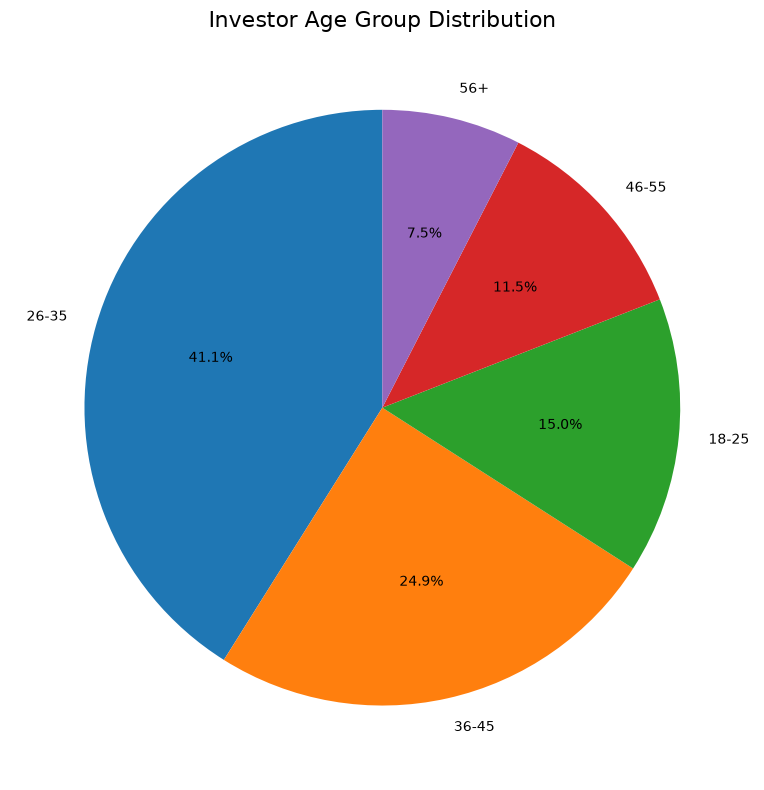

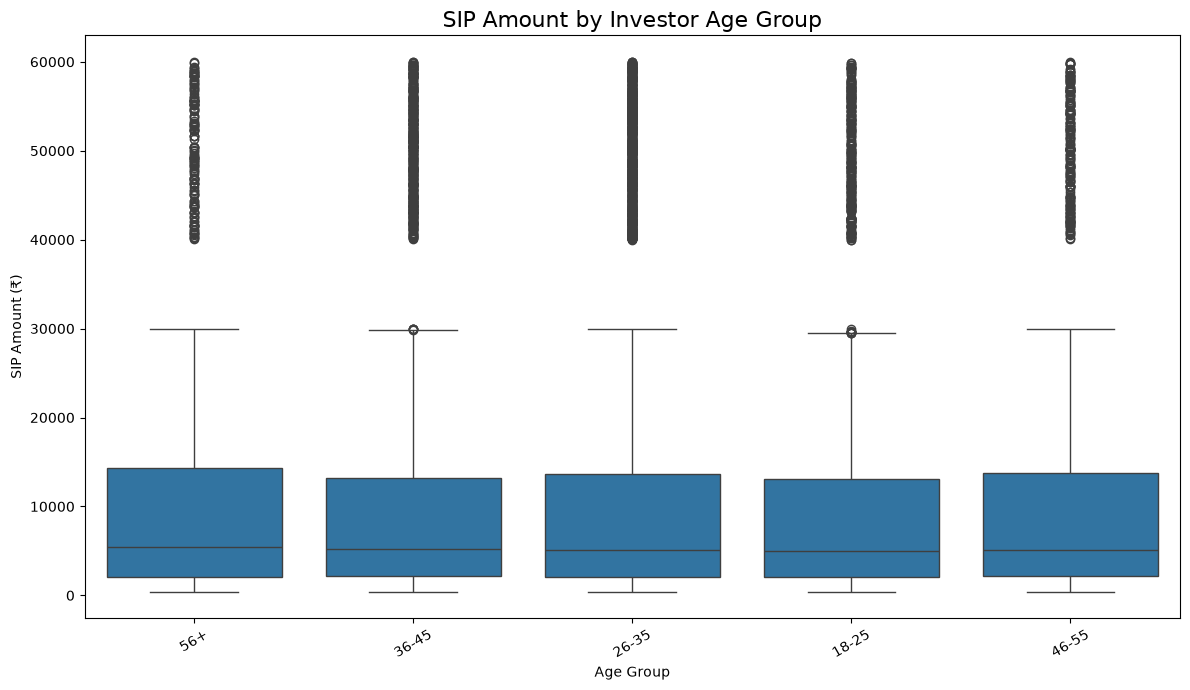

Task 5 completed successfully.
Charts saved to the Reports folder.


In [2]:
# ============================================
# DAY 3 - TASK 5: INVESTOR DEMOGRAPHICS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load investor transaction data
df = pd.read_csv("../Data/Raw/08_investor_transactions.csv")

# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns:", df.columns.tolist())
display(df.head())

# --------------------------------------------
# Use the actual columns from the dataset
# --------------------------------------------

age_col = "age_group"
amount_col = "amount_inr"
transaction_col = "transaction_type"

# Make amount numeric
df[amount_col] = pd.to_numeric(
    df[amount_col],
    errors="coerce"
)

# Remove rows missing required information
demo_df = df[
    [age_col, amount_col, transaction_col]
].dropna().copy()

# --------------------------------------------
# CHART 1: AGE GROUP DISTRIBUTION
# --------------------------------------------

age_counts = demo_df[age_col].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    age_counts.values,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Investor Age Group Distribution",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    "../Reports/Investor_Age_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# --------------------------------------------
# CHART 2: SIP AMOUNT BY AGE GROUP
# --------------------------------------------

# Keep only SIP transactions
sip_df = demo_df[
    demo_df[transaction_col]
    .astype(str)
    .str.strip()
    .str.lower()
    == "sip"
].copy()

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=sip_df,
    x=age_col,
    y=amount_col
)

plt.title(
    "SIP Amount by Investor Age Group",
    fontsize=16
)

plt.xlabel("Age Group")
plt.ylabel("SIP Amount (₹)")

plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "../Reports/SIP_Amount_by_Age_Group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Task 5 completed successfully.")
print("Charts saved to the Reports folder.")
